

# FDTD Implementation in 1D

This chapter demonstrates the implementation of the Yee algorithm in the one-dimensional case. For this scenario, we will assume a spatial arrangement of the E and H field components according to the following diagram.

<img src="./img/fdtd_03.png" width=650 alt="Jednorozmerná konfigurácia problému" scale="0.8">

### Explanation of the 1D Grid

The diagram illustrates the practical setup for a 1D FDTD simulation.

* **Spatial Staggering**: The electric field nodes ($E_z$) and magnetic field nodes ($H_y$) are spatially offset. The $H_y$ nodes are located exactly halfway between the $E_z$ nodes. This arrangement is the core of the Yee algorithm.
* **Arrays**: In a computer program, the values for $E_z$ and $H_y$ are stored in separate one-dimensional arrays. An integer index `m` in the array corresponds to a specific physical location on the grid.

### Simulation Parameters and Physical Scaling

The simulation environment for the propagation of an EM wave in 1D space will have a length of **200 nodes** and will run for a time interval of **300 steps**. The values for $E_z$ and $H_y$ will be stored in separate arrays.

The physical representation of the simulation environment depends on our choice of units. If we set the Courant number **$S_c = 1$** and choose a spatial step of **$\Delta x = 1 \, mm$**, then the corresponding time step will be:

$$
\Delta t = S_c \frac{\Delta x}{c} = \frac{1 \cdot 10^{-3} \, \text{m}}{3 \cdot 10^8 \, \text{m/s}} = 3.33 \times 10^{-12} \, \text{s} = 3.33 \, \text{ps}
$$

* **Concept**: The FDTD simulation is inherently unitless. By assigning a physical length to the spatial step $\Delta x$, we give physical meaning to all other parameters. The Courant stability condition ($S_c=1$ for 1D) directly links the size of the time step $\Delta t$ to the spatial step $\Delta x$.

### Source Excitation

We will excite the electromagnetic wave with an electric field component in the form of an exponential pulse, which is shifted in time relative to the start of the simulation. The source is applied at the first node of the grid ($m=0$).

$$
E_z^q[0] = \exp \left( -\frac{(q-30)^2}{100} \right) \, [\text{V/m}]
$$

* **Concept**: This function describes a **Gaussian pulse**.
* **Time Offset**: The term `(q-30)` shifts the peak of the pulse to the 30th time step. This provides a "soft start" for the simulation, preventing abrupt changes at $t=0$ that could introduce numerical noise.
* **Pulse Width**: The denominator `100` controls the width of the pulse. A larger value would result in a wider pulse in time.


In [17]:
from IPython.display import *
from IPython.display import Latex as lx
from sympy import latex

def ltxprint(var, value):   
    # pomocna funkcia pre formatovanu tlac premennych
    s = '$' + latex(var) + '=' + latex(value) + '$'
    #display(lx(s))
    display(s)

In [18]:
# inicializaci a  vystup skriptov v kapitole MEEP Sources

import meep as mp 
import matplotlib.pyplot as plt


dx = 100
dy = 100
area = mp.Vector3(dx, dy, 0)

def src_plot(dx, dy, data, res=1):
    # pomocna funkcia pre zobrazenie zdrojov v MEEP 
    # plotting 2D wave from source and wave cross section at y=50
    fig = plt.figure(figsize=(11,5))
    ax = fig.add_subplot(121)
     
    plt.imshow(data, interpolation='spline36', cmap='bwr', alpha=1.0, 
               extent=(0, dx, 0, dy), norm=plt.Normalize(-0.1, 0.1))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid()

    ax = fig.add_subplot(122)
    plt.plot(data[50*res,:], label='Y = 50')
    plt.xlabel('X')
    plt.grid()
    plt.legend()
    plt.show()

In [27]:
import matplotlib.pyplot as plt

def tm_plot(times, r):
    """
    Plot Ez field snapshots at selected time steps.

    Parameters
    ----------
    times : list of int
        Time steps to plot.
    r : ndarray
        2D array of shape (time, nodes) containing Ez values.
    """
    plt.figure(figsize=(10, 6))

    for i, t in enumerate(times):
        plt.subplot(len(times), 1, i + 1)
        plt.plot(r[t, :], "r-")
        plt.ylim(-1.1, 1.1)
        plt.xlim(0, r.shape[1])
        plt.legend([f"t={t}"])
        plt.grid(True)

    plt.tight_layout()
    plt.show()


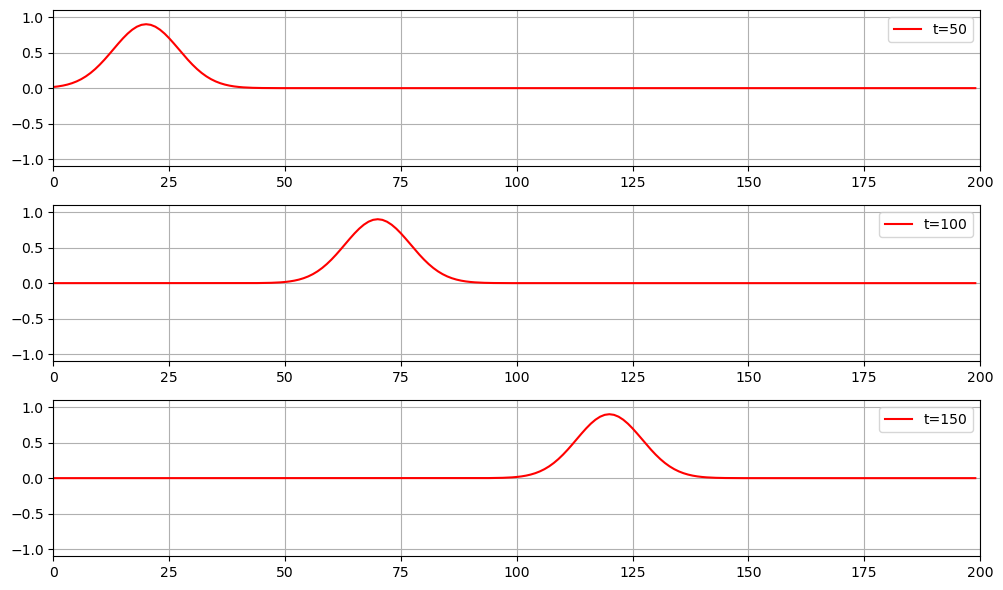

In [28]:
#%reset -sf 
%matplotlib inline
from scipy import *
import matplotlib.pyplot as plt
import numpy as np

nodes = 200
time = 300
ez = np.zeros(nodes)
hy = np.zeros(nodes)
z0 = 377.0
Sc = 1.0

r = np.zeros((time, nodes))                             # pole vysledkov

for t in range(time):
    ez[0] = np.exp(-(t - 30.)**2 / 100.) *0.9              # zdroj E vlny 
    
    for m in range(1,nodes):                         # 1...199
        ez[m] = ez[m] + (hy[m] - hy[m - 1]) * z0 * Sc    # aktualizacia Ez
    
    for m in range(nodes-1):                         # 0...198
        hy[m] = hy[m] + (ez[m + 1] - ez[m]) / z0 * Sc    # aktualizacia Hy
        
    r[t,:] += ez

tm_plot([50,100, 150], r)
#wv_plot(time, nodes, r)  
#src_plot(time, nodes, r)

**Úloha** 

Vyskúšajte výpočet s rôznymi hodnotami Courantovho čísla (0.5, 1.0, 1.1 ...)



## Boundary Conditions

In the FDTD method, boundary conditions play a crucial role. From the previous example, it is clear that a reflection of the wave occurs at the edge of the simulation space. To analyze these boundary conditions, we will simplify the previous example. We will limit the size of the environment to **5 nodes**, use a **unit impulse** as the signal, and consider the impedance of a vacuum to be equal to **1**.

### Explanation of the Concept and Simplifications

**Why are boundary conditions so important?**
FDTD simulations are performed on a finite computational grid, but they often need to model problems that exist in an open, infinite space (like an antenna radiating into the air). When a wave propagating through the grid reaches the edge, it must be absorbed without reflection. Otherwise, the reflected wave will travel back into the simulation domain and interfere with the true solution, producing non-physical and incorrect results. The rules that govern the behavior of the fields at these edges are the **boundary conditions**.

**Why are we simplifying the problem?**
To clearly understand and analyze what happens at the boundaries, we are simplifying the simulation parameters in three ways:

1.  **Grid Size of 5 Nodes**: A very small grid allows us to manually track the values of the E and H fields at each node for every time step. This makes it easy to see exactly how a wave pulse interacts with the boundary.
2.  **Unit Impulse Signal**: Using a single pulse of amplitude '1' as the source is the simplest possible excitation. It allows us to follow a single, clean wavefront as it propagates and reflects, without the complexity of a wider, more complex waveform.
3.  **Vacuum Impedance = 1**: Setting the impedance of free space ($z_0$) to 1 is a common normalization technique that simplifies the update equations. The update coefficients become much simpler, making the step-by-step calculations more straightforward and easier to follow.

These simplifications are for educational purposes to isolate and examine the fundamental behavior of waves at the edges of the FDTD grid.


In [24]:

from scipy import *
import numpy as np

def tprint(res_e, res_h, ts, te):
    # formatovana tlac tabulky
    print('        +' +'------+'*5)
    print('        |' +' E  H |'*5)
    print('--------+' +'------+'*5)
    for q in range(ts,te):
        s1 = 'q = {0:2.0f}  '.format(q)
        s2 = ''
        s3 = '        |   '
        for m in range(nodes):
            s2 += '| {0: 1.0f}   '.format(res_e[q,m])
            s3 += '{0: 1.0f} |   '.format(res_h[q,m])
        print(s1 + s2 + '|\n' + s3)
        print('--------+' +'------+'*5)

nodes = 5                                 # pocet uzlov
time = 15                                 # pocet krokov
ez = np.zeros(nodes)                        
hy = np.zeros(nodes)

res_e = np.zeros((time, nodes))
res_h = np.zeros((time, nodes))

for q in range(time):
    ez[0] = (1 if q==0 else 0)
    
    for m in range(1,nodes):                  
        ez[m] = ez[m] + (hy[m] - hy[m - 1])      # aktualizacia Ez
    
    for m in range(nodes-1): 
        hy[m] = hy[m] + (ez[m + 1] - ez[m])      # aktualizacia Hy
        
    res_h[q,:] += hy  
    res_e[q,:] += ez      
    
tprint(res_e,res_h,0,10)  

        +------+------+------+------+------+
        | E  H | E  H | E  H | E  H | E  H |
--------+------+------+------+------+------+
q =  0  |  1   |  0   |  0   |  0   |  0   |
        |   -1 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  1  |  0   |  1   |  0   |  0   |  0   |
        |    0 |   -1 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  2  |  0   |  0   |  1   |  0   |  0   |
        |    0 |    0 |   -1 |    0 |    0 |   
--------+------+------+------+------+------+
q =  3  |  0   |  0   |  0   |  1   |  0   |
        |    0 |    0 |    0 |   -1 |    0 |   
--------+------+------+------+------+------+
q =  4  |  0   |  0   |  0   |  0   |  1   |
        |    0 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  5  |  0   |  0   |  0   |  0   |  1   |
        |    0 |    0 |    0 |    1 |    0 |   
--------+------+------+------+------+------+
q =  6  |  0   |  0   |  0   |  1   |

##   Pulse Generation

In the first step of generating a pulse, the source of the EM wave—node Ez[0]—acquires a value of 1. In subsequent steps, this node will have a value of zero, regardless of the state of the adjacent nodes. The simulation runs cyclically for the entire simulation environment, repeating for values of m=0...4.

                                                               
    Ez[0] = 1                                                 q = 0
    Ez[1] = 0                                                 q = 0
    
    Hy[0] = Hy[0] + (Ez[1] - Ez[0]) =  0 + (0 - 1) = -1       q = 1/2
    Hy[1] = Hy[1] + (Ez[2] - Ez[1]) =  0 + (0 - 0) =  0       q = 1/2
    ...
                                                              nasledujuci cyklus 
    Ez[0] = 0                                                 q = 1
    Ez[1] = Ez[1] + (Hy[1] - Hy[0]) =  0 + (0 --1) =  1       q = 1
    
    Hy[0] = Hy[0] + (Ez[1] - Ez[0]) = -1 + (1 - 0) =  0       q = 1 + 1/2
    Hy[1] = Hy[1] + (Ez[2] - Ez[1]) =  0 + (0 - 1) = -1       q = 1 + 1/2
    ...
    
From the course of the calculation and the following table, it is clear how the wave gradually moves from the source toward the right edge after each update cycle.

In [25]:
tprint(res_e, res_h, 0, 4)

        +------+------+------+------+------+
        | E  H | E  H | E  H | E  H | E  H |
--------+------+------+------+------+------+
q =  0  |  1   |  0   |  0   |  0   |  0   |
        |   -1 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  1  |  0   |  1   |  0   |  0   |  0   |
        |    0 |   -1 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  2  |  0   |  0   |  1   |  0   |  0   |
        |    0 |    0 |   -1 |    0 |    0 |   
--------+------+------+------+------+------+
q =  3  |  0   |  0   |  0   |  1   |  0   |
        |    0 |    0 |    0 |   -1 |    0 |   
--------+------+------+------+------+------+


## PMC Odraz na pravej strane prostredia

Cyklickým prepočítavaním postupne prejdeme k vyhodnoteniu stavu na pravom okraji. Pretože cyklus pre Hy končí pri hodnote m-1, bude hodnota Hy[m] rovná vždy 0.
                                                             
    Ez[3] = Ez[3] + (Hy[3] - Hy[2]) = 0 + (0 - -1) =  1       q = 3
    Ez[4] = 0                                                 q = 3
    
    Hy[3] = Hy[3] + (Ez[4] - Ez[3]) = 0 + (0 -  1) = -1       q = 3 + 1/2
    Hy[4] = 0                                                 q = 3 + 1/2
    ...
    
    Ez[3] = 0                                                 q = 4
    Ez[4] = Ez[4] + (Hy[4] - Hy[3]) = 0 + (0 - -1) =  1       q = 4
    
    Hy[3] = 0                                                 q = 4 + 1/2
    Hy[4] = 0                                                 q = 4 + 1/2
    
Pri nasledujúcom cykle preto nedôjde k zmene hodnoty Ez, pretože hodnota Hy v poslednom uzle je rovná 0. 

    Ez[3] = Ez[3] + (Hy[3] - Hy[2]) = 0 + (0 -  0) =  0       q = 5
    Ez[4] = Hy[3] + (Ez[4] - Ez[3]) = 0 + (1 -  0) =  1       q = 5
    
    Hy[3] = Hy[3] + (Ez[4] - Ez[3]) = 0 + (1 -  0) =  1       q = 5 + 1/2
    Hy[4] = 0                                                 q = 5 + 1/2
    ...
    Ez[3] = Ez[3] + (Hy[3] - Hy[2]) = 0 + (1 -  0) =  1       q = 6
    Ez[4] = Ez[4] + (Hy[4] - Hy[3]) = 1 + (0 -  1) =  0       q = 6  
    
    Hy[3] = Hy[3] + (Ez[4] - Ez[3]) = 0 + (1 -  1) =  0       q = 6 + 1/2
    Hy[4] = 0                                                 q = 6 + 1/2
    
Pri odraze sa elektrická zložka zachovala, magnetická otočila, z technického hľadiska takýto stav zodpovedá odrazu vlnenia na voľnom konci vedenia. V terminológii FDTD sa takyto uzol označuje ako PMC (Perfect Magnetic Conductor).

In [6]:
tprint(res_e, res_h, 3, 7)

        +------+------+------+------+------+
        | E  H | E  H | E  H | E  H | E  H |
--------+------+------+------+------+------+
q =  3  |  0   |  0   |  0   |  1   |  0   |
        |    0 |    0 |    0 |   -1 |    0 |   
--------+------+------+------+------+------+
q =  4  |  0   |  0   |  0   |  0   |  1   |
        |    0 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  5  |  0   |  0   |  0   |  0   |  1   |
        |    0 |    0 |    0 |    1 |    0 |   
--------+------+------+------+------+------+
q =  6  |  0   |  0   |  0   |  1   |  0   |
        |    0 |    0 |    1 |    0 |    0 |   
--------+------+------+------+------+------+




## PMC Reflection on the Right Side of the Environment
By cyclical recalculation, we gradually move to the evaluation of the state at the right edge. Because the loop for Hy ends at the value m-1, the value of Hy[m] will always be 0.

In the next cycle, therefore, there will be no change in the value of Ez, because the value of Hy at the last node is equal to 0.

In [26]:
tprint(res_e, res_h, 7, 11)

        +------+------+------+------+------+
        | E  H | E  H | E  H | E  H | E  H |
--------+------+------+------+------+------+
q =  7  |  0   |  0   |  1   |  0   |  0   |
        |    0 |    1 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  8  |  0   |  1   |  0   |  0   |  0   |
        |    1 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q =  9  |  0   |  0   |  0   |  0   |  0   |
        |    1 |    0 |    0 |    0 |    0 |   
--------+------+------+------+------+------+
q = 10  |  0   | -1   |  0   |  0   |  0   |
        |    0 |    1 |    0 |    0 |    0 |   
--------+------+------+------+------+------+




For the simulation of EM wave propagation in free space, it is necessary to define the boundary conditions of the medium in such a way that reflections and subsequent interferences do not occur. The creation of reflectionless or impedance-matched boundary conditions will be discussed in the following chapters.